<a href="https://colab.research.google.com/github/luccasnn/previsao-churn/blob/main/previsao_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# dataset real
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nDistribuição de Attrition (churn):")
print(df['Attrition'].value_counts())
df.head()

Shape: (1470, 35)

Distribuição de Attrition (churn):
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
# converte para numero
le = LabelEncoder()
df_model = df.copy()

colunas_categoricas = df_model.select_dtypes(include='object').columns
for col in colunas_categoricas:
    df_model[col] = le.fit_transform(df_model[col])

# separacao features e target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# splita o treino/teste///stratify=y garante mesma proporcao treino teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")
print(f"\nDistribuição no teste:")
print(y_test.value_counts())

Treino: 1176 registros
Teste: 294 registros

Distribuição no teste:
Attrition
0    247
1     47
Name: count, dtype: int64


In [16]:
# treina XGBoost
modelo = xgb.XGBClassifier(
    n_estimators=100, #quantas arvores
    max_depth=4, #profundidade da arvore
    learning_rate=0.1, #quanto cada arvore ajuda na correcao
    scale_pos_weight=5,  # compensa o desbalanceamento (5 -> ~5x o tamanho )
    random_state=42,
    eval_metric='logloss'#logloss penaliza erros rigorosamente
)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

print("=== RESULTADOS ===")
print(classification_report(y_test, y_pred, target_names=['Ficou', 'Saiu']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")


=== RESULTADOS ===
              precision    recall  f1-score   support

       Ficou       0.90      0.90      0.90       247
        Saiu       0.47      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.83      0.83      0.83       294

AUC-ROC: 0.803


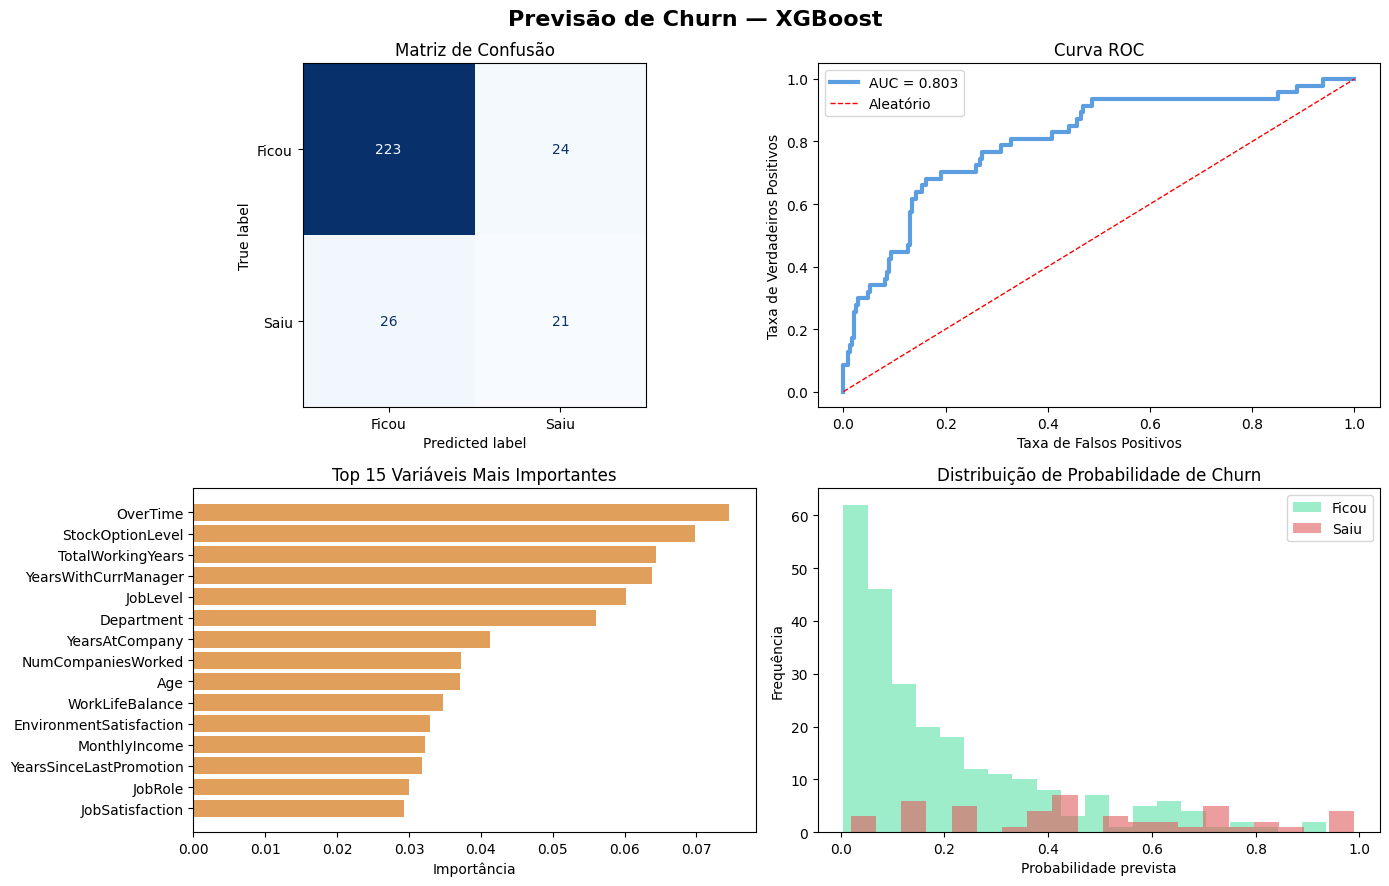

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Previsão de Churn — XGBoost', fontsize=16, fontweight='bold')

# 1. Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ficou', 'Saiu'])
disp.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Matriz de Confusão')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color='#5c9ee0', linewidth=3, label=f'AUC = 0.803')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Aleatório')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].set_xlabel('Taxa de Falsos Positivos')
axes[0, 1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0, 1].legend()

# 3. Feature importance
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
top15 = importancias.sort_values(ascending=True).tail(15)
axes[1, 0].barh(top15.index, top15.values, color='#e0a05c')
axes[1, 0].set_title('Top 15 Variáveis Mais Importantes')
axes[1, 0].set_xlabel('Importância')

# 4. Distribuição de probabilidade
proba_ficou = y_pred_proba[y_test == 0]
proba_saiu = y_pred_proba[y_test == 1]
axes[1, 1].hist(proba_ficou, bins=20, alpha=0.6, color='#5ce0a8', label='Ficou')
axes[1, 1].hist(proba_saiu, bins=20, alpha=0.6, color='#e05c5c', label='Saiu')
axes[1, 1].set_title('Distribuição de Probabilidade de Churn')
axes[1, 1].set_xlabel('Probabilidade prevista')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('previsao_churn.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ajusta threshold para 0.3
threshold = 0.3
y_pred_ajustado = (y_pred_proba >= threshold).astype(int)

print(f"=== RESULTADOS COM THRESHOLD {threshold} ===")
print(classification_report(y_test, y_pred_ajustado, target_names=['Ficou', 'Saiu']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

=== RESULTADOS COM THRESHOLD 0.3 ===
              precision    recall  f1-score   support

       Ficou       0.93      0.77      0.85       247
        Saiu       0.37      0.70      0.49        47

    accuracy                           0.76       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.76      0.79       294

AUC-ROC: 0.803


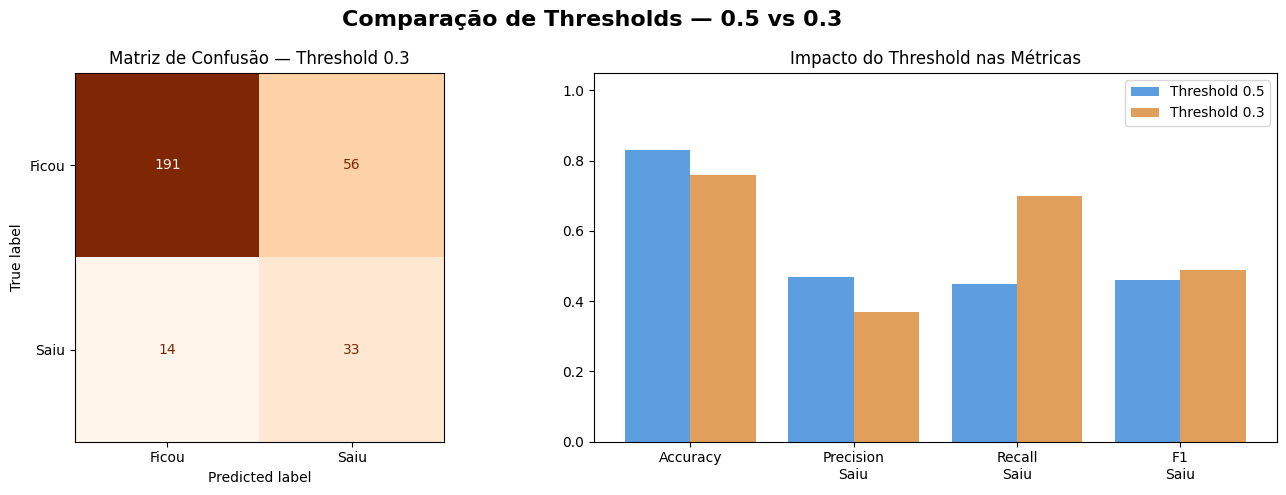

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Thresholds — 0.5 vs 0.3', fontsize=16, fontweight='bold')

# 1. Matriz de confusão threshold 0.3
cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)
disp = ConfusionMatrixDisplay(cm_ajustado, display_labels=['Ficou', 'Saiu'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Matriz de Confusão — Threshold 0.3')

# 2. Comparação de métricas
metricas = ['Accuracy', 'Precision\nSaiu', 'Recall\nSaiu', 'F1\nSaiu']
vals_05 = [0.83, 0.47, 0.45, 0.46]
vals_03 = [0.76, 0.37, 0.70, 0.49]
x = range(len(metricas))
axes[1].bar([i - 0.2 for i in x], vals_05, width=0.4, label='Threshold 0.5', color='#5c9ee0')
axes[1].bar([i + 0.2 for i in x], vals_03, width=0.4, label='Threshold 0.3', color='#e0a05c')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metricas)
axes[1].set_title('Impacto do Threshold nas Métricas')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('comparacao_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

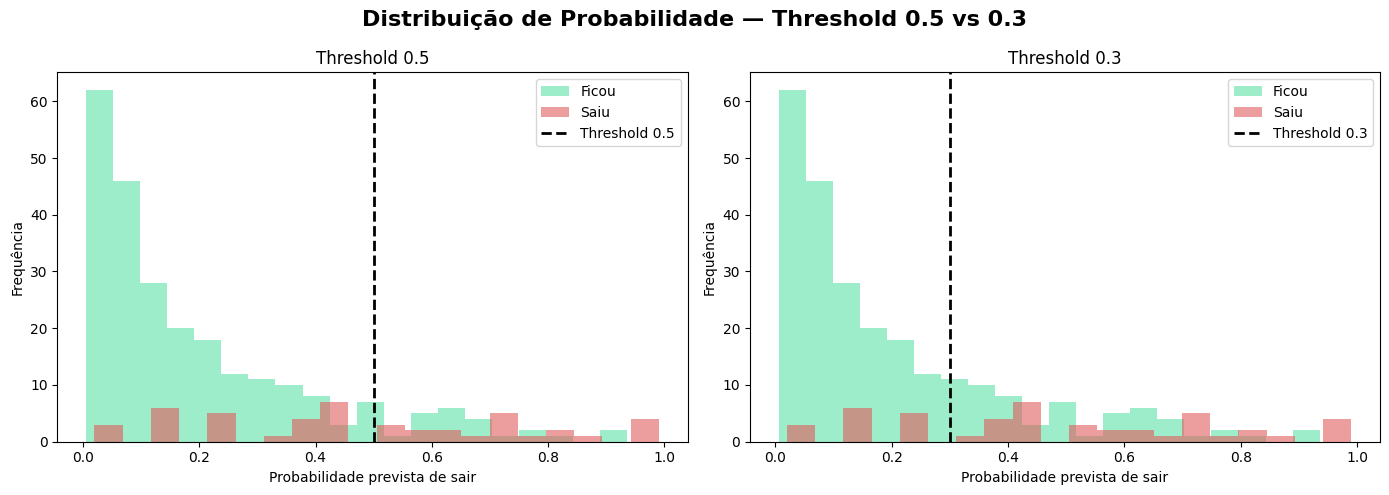

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Probabilidade — Threshold 0.5 vs 0.3', fontsize=16, fontweight='bold')

# Threshold 0.5
proba_ficou = y_pred_proba[y_test == 0]
proba_saiu = y_pred_proba[y_test == 1]

axes[0].hist(proba_ficou, bins=20, alpha=0.6, color='#5ce0a8', label='Ficou')
axes[0].hist(proba_saiu, bins=20, alpha=0.6, color='#e05c5c', label='Saiu')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold 0.5')
axes[0].set_title('Threshold 0.5')
axes[0].set_xlabel('Probabilidade prevista de sair')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Threshold 0.3
axes[1].hist(proba_ficou, bins=20, alpha=0.6, color='#5ce0a8', label='Ficou')
axes[1].hist(proba_saiu, bins=20, alpha=0.6, color='#e05c5c', label='Saiu')
axes[1].axvline(x=0.3, color='black', linestyle='--', linewidth=2, label='Threshold 0.3')
axes[1].set_title('Threshold 0.3')
axes[1].set_xlabel('Probabilidade prevista de sair')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribuicao_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
from google.colab import files


files.download('previsao_churn.png')
files.download('comparacao_threshold.png')
files.download('distribuicao_threshold.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>